# Exploring `Cut2.root`

This notebook uses **uproot** + **awkward-array** to inspect the ROOT file structure,
list trees/branches/types, preview data, and make quick diagnostic plots.

In [1]:
import uproot
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("All imports OK ✓")

All imports OK ✓


## 1. Open the ROOT file & list top-level keys

In [2]:
file_path = Path("../Cut2.root")  # one level up from cut2_root_explore/

if not file_path.exists():
    raise FileNotFoundError(f"Could not find {file_path.resolve()}")

f = uproot.open(file_path)
print(f"Opened: {file_path.resolve()}")
print(f"File size: {file_path.stat().st_size / 1e9:.2f} GB")
print()
print("Top-level keys:")
for key in f.keys():
    obj = f[key]
    print(f"  {key:40s}  type = {type(obj).__name__}")

Opened: C:\MY_CODES\NIRAB_DAI\Cut2.root
File size: 2.11 GB

Top-level keys:
  Reco_Tree;2                               type = Model_TTree_v20
  Reco_Tree;1                               type = Model_TTree_v20
  Truth_Info;2                              type = Model_TTree_v20
  Truth_Info;1                              type = Model_TTree_v20
  Line_Candidates;2                         type = Model_TTree_v20
  Line_Candidates;1                         type = Model_TTree_v20


## 2. Discover all TTree objects

In [3]:
trees = {}
for key in f.keys():
    obj = f[key]
    if isinstance(obj, uproot.TTree):
        # strip cycle number (e.g., ";1") for cleaner names
        clean_name = key.split(";")[0]
        trees[clean_name] = obj

if not trees:
    # Maybe the trees are nested inside TDirectoryFile objects
    for key in f.keys():
        obj = f[key]
        if hasattr(obj, 'keys'):  # directory-like
            for subkey in obj.keys():
                subobj = obj[subkey]
                if isinstance(subobj, uproot.TTree):
                    clean_name = f"{key.split(';')[0]}/{subkey.split(';')[0]}"
                    trees[clean_name] = subobj

print(f"Found {len(trees)} TTree(s):")
for name, tree in trees.items():
    print(f"  {name}  →  {tree.num_entries:,} entries, {len(tree.keys())} branches")

Found 3 TTree(s):
  Reco_Tree  →  1,000 entries, 37 branches
  Truth_Info  →  996 entries, 180 branches
  Line_Candidates  →  1,000 entries, 171 branches


## 3. Branch catalogue — name, type, interpretation, jagged?

In [4]:
def branch_info(tree, tree_name="tree"):
    """Return a DataFrame describing every branch in the tree."""
    rows = []
    for bname in tree.keys():
        branch = tree[bname]
        try:
            interp = branch.interpretation
            typename = str(branch.typename)
        except Exception:
            interp = "<unreadable>"
            typename = "<unknown>"

        is_jagged = "var" in str(interp).lower() or "jagged" in str(interp).lower() or "[]" in typename
        rows.append({
            "tree": tree_name,
            "branch": bname,
            "typename": typename,
            "interpretation": str(interp),
            "jagged": is_jagged,
        })
    return pd.DataFrame(rows)

branch_dfs = []
for name, tree in trees.items():
    df = branch_info(tree, name)
    branch_dfs.append(df)

all_branches = pd.concat(branch_dfs, ignore_index=True)
print(f"Total branches across all trees: {len(all_branches)}")
print()
all_branches

Total branches across all trees: 388



,tree,branch,typename,interpretation,jagged
0,Reco_Tree,EventNo,int32_t,AsDtype('>i4'),False
1,Reco_Tree,SliceNo,int32_t,AsDtype('>i4'),False
2,Reco_Tree,SpillNo,int32_t,AsDtype('>i4'),False
3,Reco_Tree,RunNo,int32_t,AsDtype('>i4'),False
4,Reco_Tree,nTracks,int32_t,AsDtype('>i4'),False
...,...,...,...,...,...
383,Line_Candidates,RecoHitPE,float[],AsJagged(AsDtype('>f4')),True
384,Line_Candidates,RecoHitBar,int32_t[],AsJagged(AsDtype('>i4')),True
385,Line_Candidates,RecoHitBarType,int32_t[],AsJagged(AsDtype('>i4')),True
386,Line_Candidates,RecoHitPlane,int32_t[],AsJagged(AsDtype('>i4')),True


### 3a. Scalar vs. jagged summary

In [5]:
print("Scalar branches:")
scalars = all_branches[~all_branches["jagged"]]
print(scalars[["tree", "branch", "typename"]].to_string(index=False))
print()
print("Jagged (variable-length) branches:")
jagged = all_branches[all_branches["jagged"]]
print(jagged[["tree", "branch", "typename"]].to_string(index=False))

Scalar branches:
           tree                                branch                 typename
      Reco_Tree                               EventNo                  int32_t
      Reco_Tree                               SliceNo                  int32_t
      Reco_Tree                               SpillNo                  int32_t
      Reco_Tree                                 RunNo                  int32_t
      Reco_Tree                               nTracks                  int32_t
      Reco_Tree                    TimeSliceStartTime                    float
      Reco_Tree                      TimeSliceEndTime                    float
     Truth_Info                               EventNo                  int32_t
     Truth_Info                               SpillNo                  int32_t
     Truth_Info                                 RunNo                  int32_t
     Truth_Info                                  IsCC                     bool
     Truth_Info                    

## 4. Sample rows — first 5 entries for every branch

In [6]:
N_PREVIEW = 5

for tree_name, tree in trees.items():
    print(f"\n{'='*70}")
    print(f"Tree: {tree_name}   (showing first {N_PREVIEW} entries)")
    print(f"{'='*70}")
    for bname in tree.keys():
        try:
            data = tree[bname].array(entry_stop=N_PREVIEW)
            print(f"\n  {bname}:")
            for i, val in enumerate(data):
                print(f"    [{i}] {val}")
        except Exception as e:
            print(f"\n  {bname}: <could not read — {e}>")


Tree: Reco_Tree   (showing first 5 entries)

  EventNo:
    [0] 499
    [1] 1049
    [2] 2164
    [3] 2664
    [4] 3254

  SliceNo:
    [0] 20
    [1] 67
    [2] 59
    [3] 4
    [4] 41

  SpillNo:
    [0] 0
    [1] 1
    [2] 3
    [3] 4
    [4] 5

  RunNo:
    [0] 1000024590
    [1] 1000024590
    [2] 1000024592
    [3] 1000024592
    [4] 1000024593

  nTracks:
    [0] 2
    [1] 2
    [2] 2
    [3] 2
    [4] 2

  nHits:
    [0] [48, 22]
    [1] [38, 17]
    [2] [19, 17]
    [3] [39, 30]
    [4] [27, 15]

  TrackHitPos:
    [0] [[[-2.16e+03, -830, 1.75e+04], [...], ..., [-1e+09, -1e+09, -1e+09]], ...]
    [1] [[[183, -169, 1.38e+04], [165, ...], ..., [...], [-1e+09, -1e+09, -1e+09]], ...]
    [2] [[[-1.3e+03, -454, 1.76e+04], [...], ..., [...], [-1e+09, -1e+09, -1e+09]], ...]
    [3] [[[607, -844, 1.37e+04], [590, ...], ..., [...], [-1e+09, -1e+09, -1e+09]], ...]
    [4] [[[-3.13e+03, -2.21e+03, 1.66e+04], [...], ..., [-1e+09, -1e+09, -1e+09]], ...]

  nKalmanNodes:
    [0] [46, 17]
 

## 5. Jagged-array structure: length distribution

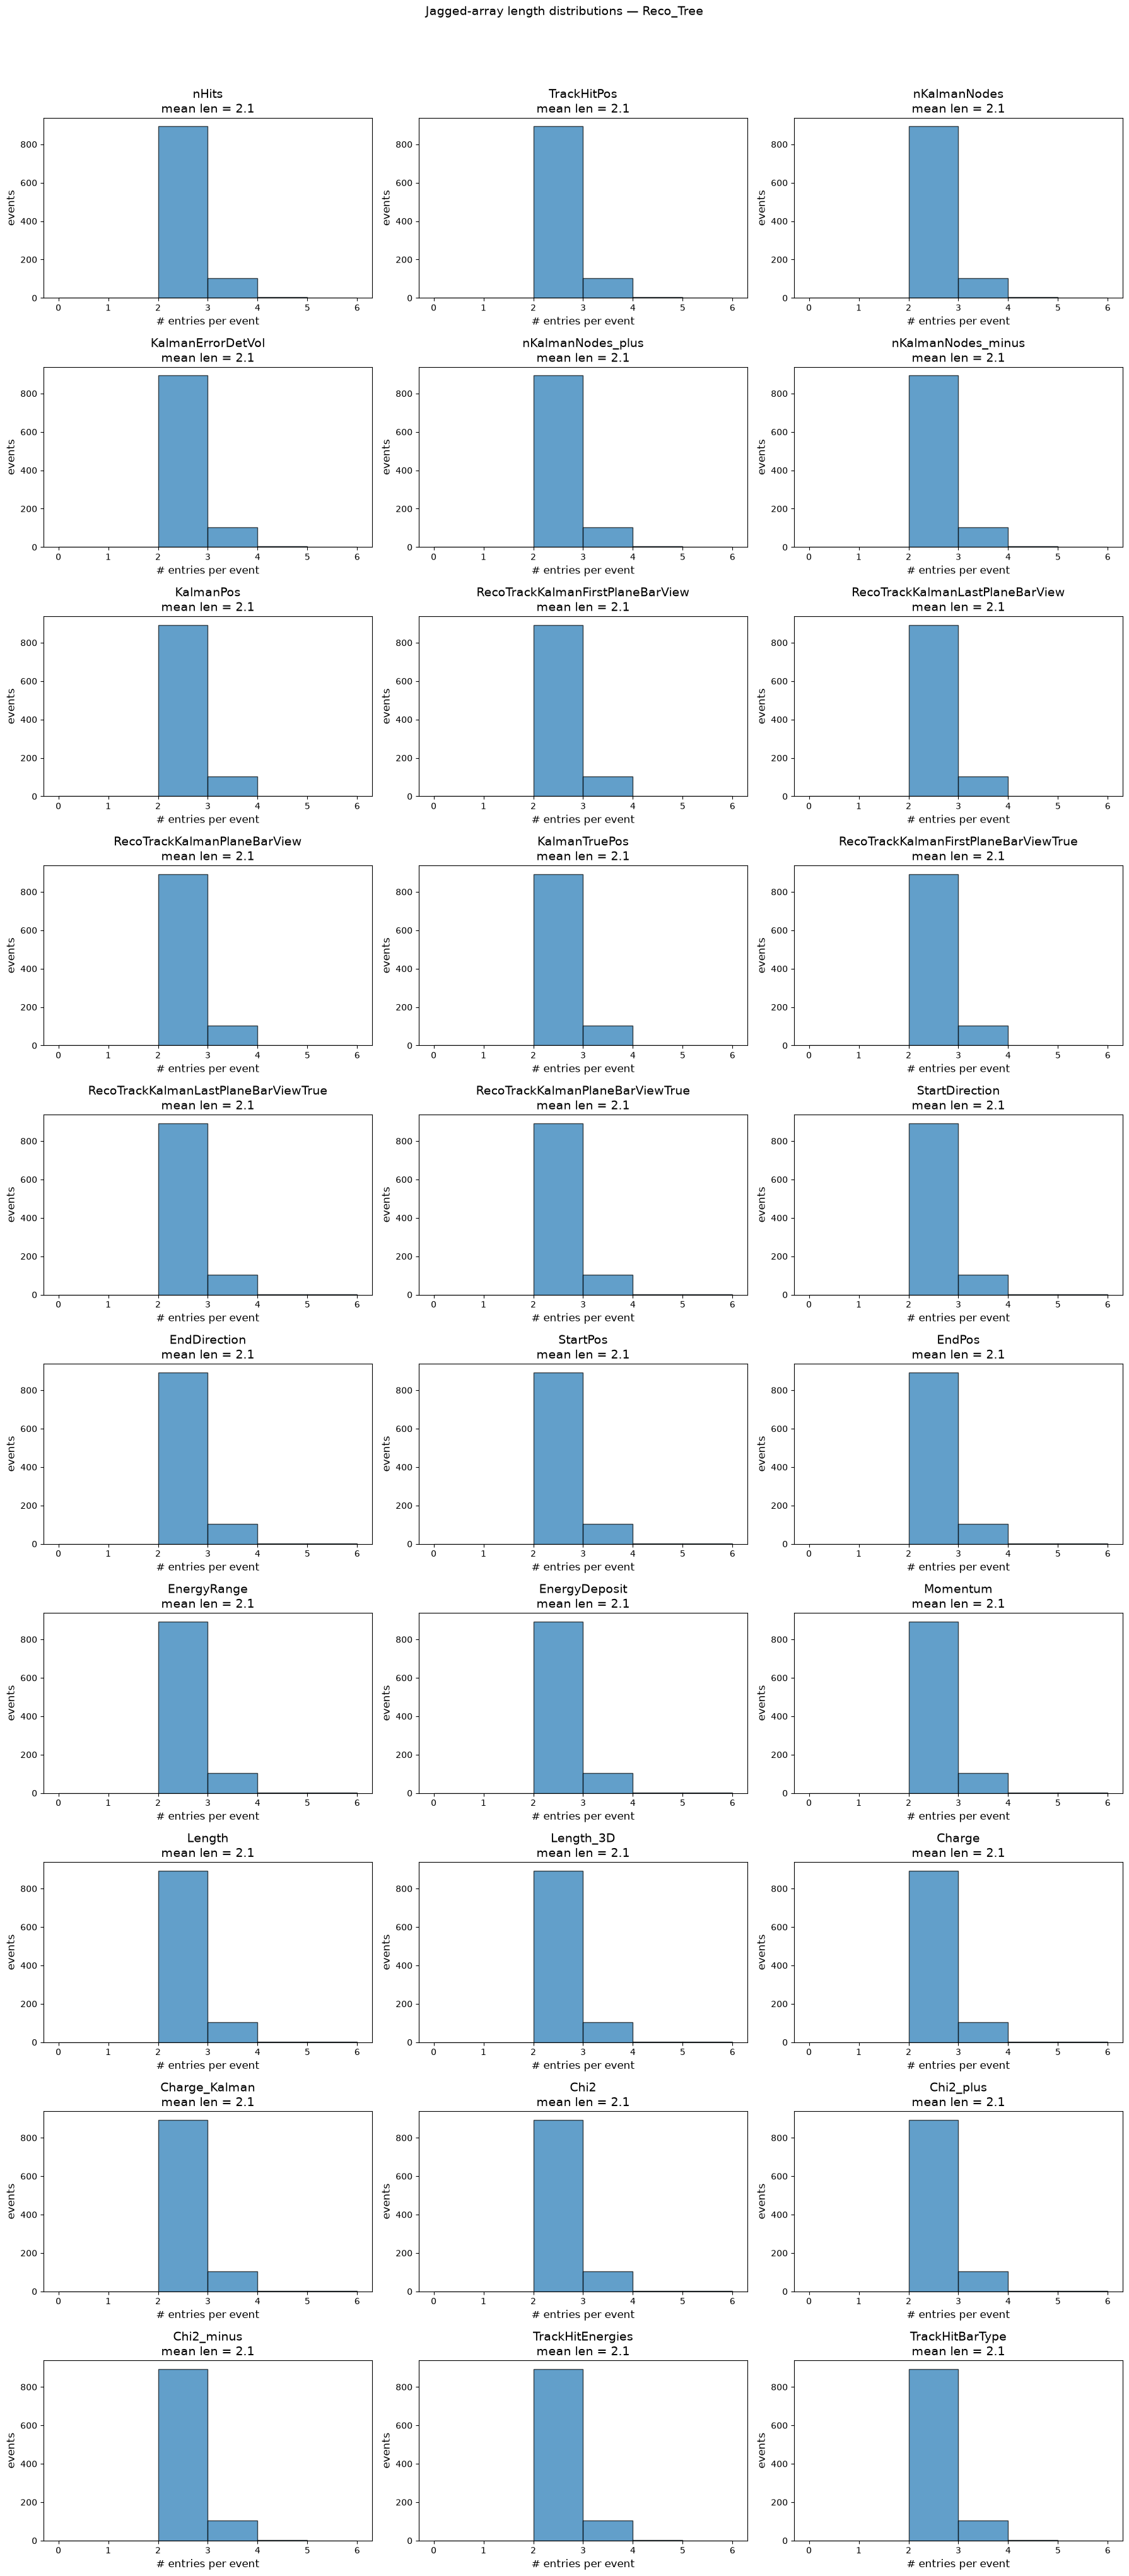

KeyboardInterrupt: 

In [ ]:
MAX_ENTRIES = 100_000  # read at most this many entries for diagnostics

for tree_name, tree in trees.items():
    jagged_branches = all_branches[(all_branches["tree"] == tree_name) & all_branches["jagged"]]["branch"].tolist()
    if not jagged_branches:
        print(f"No jagged branches in tree '{tree_name}'.")
        continue

    n_to_plot = len(jagged_branches)
    ncols = min(3, n_to_plot)
    nrows = (n_to_plot + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

    for idx, bname in enumerate(jagged_branches):
        ax = axes[idx // ncols][idx % ncols]
        try:
            data = tree[bname].array(entry_stop=MAX_ENTRIES)
            lengths = ak.num(data)
            np_lengths = ak.to_numpy(lengths)
            ax.hist(np_lengths, bins=range(0, int(np_lengths.max()) + 2), edgecolor="black", alpha=0.7)
            ax.set_title(f"{bname}\nmean len = {np_lengths.mean():.1f}")
            ax.set_xlabel("# entries per event")
            ax.set_ylabel("events")
        except Exception as e:
            ax.set_title(f"{bname}\n<error: {e}>")

    # hide unused axes
    for idx in range(n_to_plot, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"Jagged-array length distributions — {tree_name}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Quick histograms — scalar branches

In [ ]:
for tree_name, tree in trees.items():
    scalar_branches = all_branches[(all_branches["tree"] == tree_name) & (~all_branches["jagged"])]["branch"].tolist()
    if not scalar_branches:
        print(f"No scalar branches in tree '{tree_name}'.")
        continue

    n_to_plot = len(scalar_branches)
    ncols = min(3, n_to_plot)
    nrows = (n_to_plot + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

    for idx, bname in enumerate(scalar_branches):
        ax = axes[idx // ncols][idx % ncols]
        try:
            data = tree[bname].array(entry_stop=MAX_ENTRIES)
            np_data = ak.to_numpy(data)
            # filter out non-finite values
            np_data = np_data[np.isfinite(np_data)]
            ax.hist(np_data, bins=100, edgecolor="black", alpha=0.7, linewidth=0.5)
            ax.set_title(f"{bname}")
            ax.set_xlabel(bname)
            ax.set_ylabel("entries")
            # add stats box
            stats_text = f"N={len(np_data):,}\nμ={np_data.mean():.3g}\nσ={np_data.std():.3g}"
            ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
                    va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))
        except Exception as e:
            ax.set_title(f"{bname}\n<error: {e}>")

    for idx in range(n_to_plot, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"Scalar branch distributions — {tree_name}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Quick histograms — jagged branches (flattened)

In [ ]:
for tree_name, tree in trees.items():
    jagged_branches = all_branches[(all_branches["tree"] == tree_name) & all_branches["jagged"]]["branch"].tolist()
    if not jagged_branches:
        print(f"No jagged branches in tree '{tree_name}'.")
        continue

    n_to_plot = len(jagged_branches)
    ncols = min(3, n_to_plot)
    nrows = (n_to_plot + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

    for idx, bname in enumerate(jagged_branches):
        ax = axes[idx // ncols][idx % ncols]
        try:
            data = tree[bname].array(entry_stop=MAX_ENTRIES)
            flat = ak.flatten(data)
            np_flat = ak.to_numpy(flat).astype(float)
            np_flat = np_flat[np.isfinite(np_flat)]
            ax.hist(np_flat, bins=100, edgecolor="black", alpha=0.7, linewidth=0.5)
            ax.set_title(f"{bname} (flattened)")
            ax.set_xlabel(bname)
            ax.set_ylabel("entries")
            stats_text = f"N={len(np_flat):,}\nμ={np_flat.mean():.3g}\nσ={np_flat.std():.3g}"
            ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
                    va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))
        except Exception as e:
            ax.set_title(f"{bname}\n<error: {e}>")

    for idx in range(n_to_plot, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"Jagged branch distributions (flattened) — {tree_name}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Summary

This notebook has:
1. Opened `Cut2.root` and listed all top-level keys
2. Discovered all TTrees (including inside subdirectories)
3. Catalogued every branch: name, C++ typename, uproot interpretation, scalar vs. jagged
4. Shown sample rows (first 5 entries per branch)
5. Plotted jagged-array length distributions (how many sub-entries per event)
6. Plotted scalar branch distributions with stats boxes
7. Plotted flattened jagged branch distributions with stats boxes

**Next steps:** use the branch catalogue above to drill into specific physics quantities.